<a href="https://colab.research.google.com/github/mugishaalex24682-cloud/bcs3101-capstone/blob/main/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# BCS3101 Capstone — Heart Disease Prediction
# Name: MUGISHA ALEX
# Reg Number: 2024/A/KCS/5461/F

print("Environment ready.")

Environment ready.


## Step 2: Load the Heart Disease Dataset

We fetch the official UCI Heart Disease dataset directly from the
UCI Machine Learning Repository.

In [24]:
# Install the UCI ML repository package
!pip install ucimlrepo -q

In [25]:
# Import libraries
import pandas as pd
import numpy as np

# Fetch the dataset from UCI
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)  # id=45 is Heart Disease

# Separate features (X) and target (y)
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine for inspection
df = pd.concat([X, y], axis=1)

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [26]:
# Data types and non-null counts
print("=" * 50)
print("DATA TYPES AND NON-NULL COUNTS")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(df.columns.tolist())

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))
print(f"\nTotal missing cells: {df.isna().sum().sum()}")

DATA TYPES AND NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

COLUMN NAMES
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

MISSING VALUES
ca      4
thal    2
dtype: int64

Tota

## Step 4: Visual Sanity Check

Before modelling, we look at the data. Four questions we want to answer:

1. What do the numeric features look like? (histograms)
2. Are there outliers? (boxplots)
3. Which features correlate with the target? (correlation heatmap)
4. Are the classes balanced? (bar chart)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

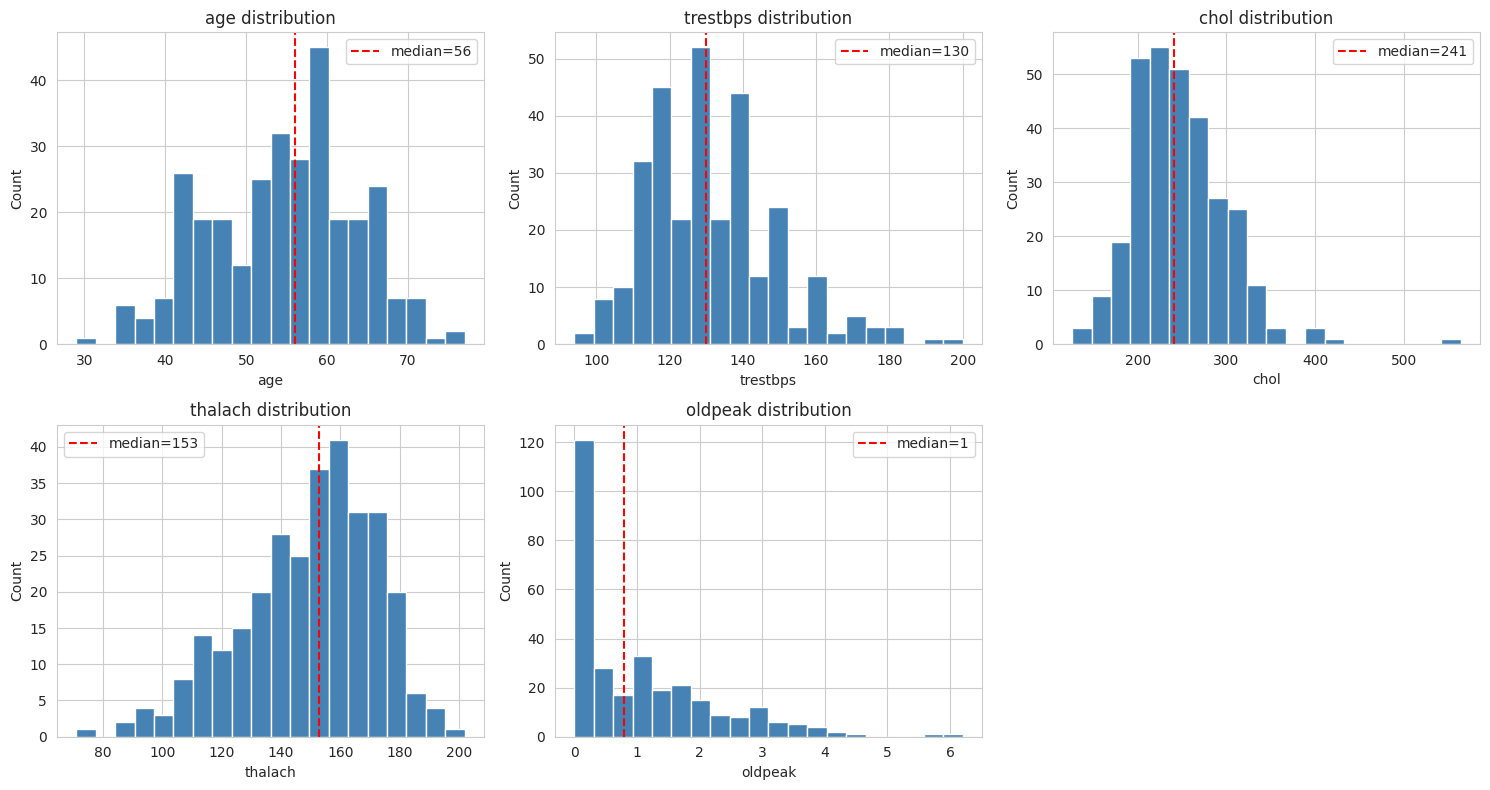

In [28]:
# Histograms of all numeric features
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].median(), color='red', linestyle='--',
                    label=f'median={df[col].median():.0f}')
    axes[i].legend()

# Hide the empty 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('feature_histograms.png', dpi=100, bbox_inches='tight')
plt.show()

KeyError: 'target'

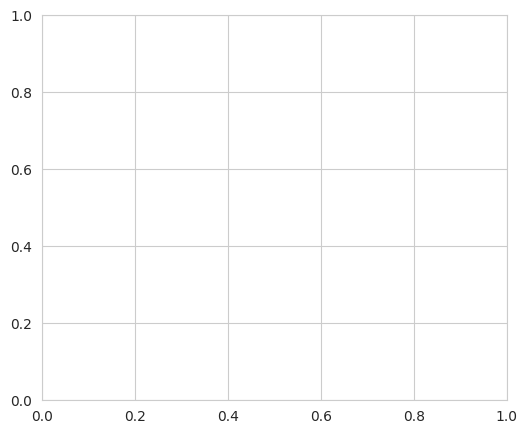

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))

counts = df['target'].value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['steelblue', 'firebrick'])

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count + 3,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center')

ax.set_title('Target Variable: Class Balance')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.savefig('target_balance.png', dpi=100, bbox_inches='tight')
plt.show()

In [30]:
print("df exists:", 'df' in dir())
if 'df' in dir():
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())

df exists: True
Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [31]:
print("=== DIAGNOSTIC ===")
print("df exists:", 'df' in dir())
if 'df' in dir():
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Has target:", 'target' in df.columns)
    print("Has num:", 'num' in df.columns)

=== DIAGNOSTIC ===
df exists: True
Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Has target: False
Has num: True


In [32]:
# Step 3 (re-run): Binarise the target
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

# Verify
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nTarget distribution:")
print(df['target'].value_counts().sort_index())
print(f"\nProportions:")
print(df['target'].value_counts(normalize=True).round(3))

Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Proportions:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


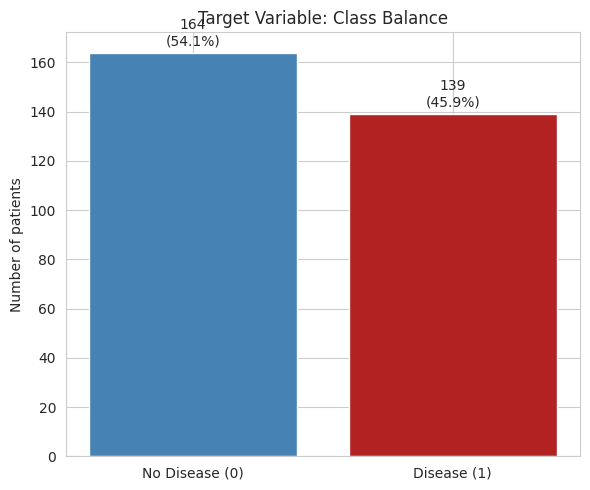

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))

counts = df['target'].value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['steelblue', 'firebrick'])

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count + 3,
            f'{count}\n({count/len(df)*100:.1f}%)', ha='center')

ax.set_title('Target Variable: Class Balance')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.savefig('target_balance.png', dpi=100, bbox_inches='tight')
plt.show()

In [34]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Has target:", 'target' in df.columns)
print("Has num:", 'num' in df.columns)
print("\nTarget values:")
print(df['target'].value_counts().sort_index())

Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Has target: True
Has num: False

Target values:
target
0    164
1    139
Name: count, dtype: int64


## Step 5: Split Train/Test BEFORE Preprocessing

We hold out 20% of the data as a test set. The model will NEVER see it during
training or tuning. Only at the very end do we evaluate on it.

Critically, we split BEFORE any scaling, encoding, or imputation. This prevents
data leakage — the test set's statistics must not influence the preprocessing.
We handle scaling and imputation later inside a scikit-learn Pipeline, so those
steps only "see" the training data.

In [35]:
from sklearn.model_selection import train_test_split

# Feature columns (everything except target)
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# X = features, y = target
X = df[feature_cols].copy()
y = df['target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\ny distribution:")
print(y.value_counts(normalize=True).round(3))

X shape: (303, 13)
y shape: (303,)

y distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% held out for testing
    random_state=42,     # so the split is reproducible
    stratify=y           # preserves class balance in both sets
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 242 samples
Test set:     61 samples

Train target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

Test target distribution:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


In [37]:
print("Any overlap between train and test?")
print("Overlapping row indices:",
      len(set(X_train.index) & set(X_test.index)))

print("\nTotal rows accounted for:", len(X_train) + len(X_test), "of", len(X))

Any overlap between train and test?
Overlapping row indices: 0

Total rows accounted for: 303 of 303


## Step 6: Leakage-Safe Preprocessing Pipeline

We build a `ColumnTransformer` that applies the right preprocessing to each
type of column:

- **Numeric columns** → impute missing with median → scale with StandardScaler
- **Categorical columns** → impute missing with most-frequent value → one-hot encode

This preprocessor lives inside a `Pipeline` with the classifier. When we call
`pipeline.fit(X_train, y_train)`, the preprocessor learns ONLY from `X_train`.
When we call `pipeline.predict(X_test)`, it applies those learned parameters to
`X_test`. No leakage. Fully reproducible.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Column types
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang',
                        'slope', 'ca', 'thal']

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine both into one ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor built.")
print(f"Numeric features:     {numeric_features}")
print(f"Categorical features: {categorical_features}")

Preprocessor built.
Numeric features:     ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [39]:
# Fit preprocessor on training data ONLY
X_train_processed = preprocessor.fit_transform(X_train)

print(f"Original training shape: {X_train.shape}")
print(f"After preprocessing:     {X_train_processed.shape}")
print(f"\nFirst 3 rows (processed):")
print(X_train_processed[:3])

Original training shape: (242, 13)
After preprocessing:     (242, 20)

First 3 rows (processed):
[[-0.72948484 -0.39569185  0.4581394   0.70837124 -0.44544493  1.
   0.          0.          1.          0.          0.          1.
   0.          1.          0.          0.          0.          0.
   0.          1.        ]
 [ 0.05016647 -0.05451337  0.23059762  0.22249537 -0.89162735  1.
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [-0.06121229  0.0592128   0.72360482  0.3991775  -0.89162735  0.
   1.          0.          0.          1.          0.          1.
   1.          0.          0.          1.          0.          0.
   0.          0.        ]]


In [40]:
import numpy as np

print("Any NaN in processed train?",
      np.isnan(X_train_processed).any())
print("Any NaN in original train?",
      X_train.isna().any().any())

Any NaN in processed train? False
Any NaN in original train? True


In [41]:
print("Original train shape:", X_train.shape)
print("Processed train shape:", X_train_processed.shape)
print("Any NaN in processed train:", np.isnan(X_train_processed).any())
print("Any NaN in original train:", X_train.isna().any().any())

Original train shape: (242, 13)
Processed train shape: (242, 20)
Any NaN in processed train: False
Any NaN in original train: True


## Step 7: First Model — Logistic Regression

Logistic regression is a linear classifier: it learns a weight for each feature,
computes a weighted sum, squashes it through the sigmoid function into a
probability (0–1), and predicts the positive class if that probability exceeds
0.5.

We use it as our baseline. If more complex models can't beat it, they're not
worth using.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

print("Imports ready.")

Imports ready.


In [43]:
# Build the pipeline: preprocessor + logistic regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train on the training set
lr_pipeline.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [44]:
# Predict on the test set (data the model has NEVER seen)
y_pred = lr_pipeline.predict(X_test)

# Metrics
print("=" * 50)
print("LOGISTIC REGRESSION — TEST SET PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")

LOGISTIC REGRESSION — TEST SET PERFORMANCE
Accuracy:  0.8689
Precision: 0.8333
Recall:    0.8929
F1:        0.8621


In [45]:
print(classification_report(y_test, y_pred,
                            target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.90      0.85      0.88        33
     Disease       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



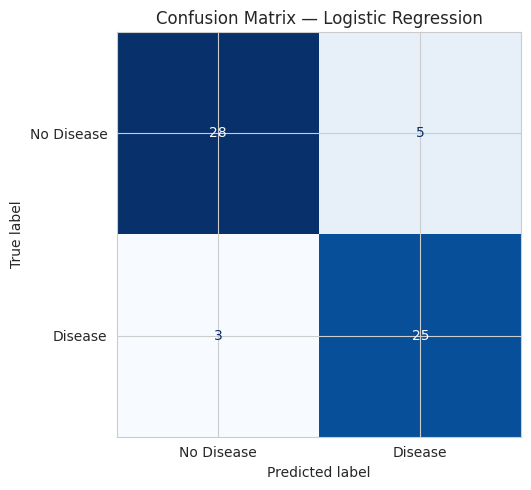

True Negatives:  28
False Positives: 5
False Negatives: 3
True Positives:  25


In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_lr.png', dpi=100, bbox_inches='tight')
plt.show()

# Print raw numbers
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

## Step 8: Train and Compare Five Classification Models

We train four more genuinely different classifiers, using the SAME
preprocessing pipeline and the SAME train/test split. This ensures a fair
comparison — the only thing changing is the classifier itself.

Models: Decision Tree, k-Nearest Neighbours, Random Forest, Gradient Boosting.

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [48]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'k-Nearest Neighbours':KNeighborsClassifier(n_neighbors=5),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print(f"Models ready: {list(models.keys())}")

Models ready: ['Logistic Regression', 'Decision Tree', 'k-Nearest Neighbours', 'Random Forest', 'Gradient Boosting']


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

for name, model in models.items():
    # Build pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    # Evaluate
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'model':     pipe  # store the trained pipeline for later
    }

    print(f"{name}")
    print(f"  Accuracy:  {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall:    {results[name]['recall']:.4f}")
    print(f"  F1:        {results[name]['f1']:.4f}")
    print()

Logistic Regression
  Accuracy:  0.8689
  Precision: 0.8333
  Recall:    0.8929
  F1:        0.8621

Decision Tree
  Accuracy:  0.6721
  Precision: 0.6667
  Recall:    0.5714
  F1:        0.6154

k-Nearest Neighbours
  Accuracy:  0.9344
  Precision: 0.9000
  Recall:    0.9643
  F1:        0.9310

Random Forest
  Accuracy:  0.8689
  Precision: 0.8333
  Recall:    0.8929
  F1:        0.8621

Gradient Boosting
  Accuracy:  0.8689
  Precision: 0.8125
  Recall:    0.9286
  F1:        0.8667



In [50]:
import pandas as pd

comparison = pd.DataFrame({
    'Model':     list(results.keys()),
    'Accuracy':  [results[m]['accuracy']  for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall':    [results[m]['recall']    for m in results],
    'F1':        [results[m]['f1']        for m in results]
}).round(4)

# Sort by F1 (or by accuracy — we'll discuss which)
comparison = comparison.sort_values('F1', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

               Model  Accuracy  Precision  Recall     F1
k-Nearest Neighbours    0.9344     0.9000  0.9643 0.9310
   Gradient Boosting    0.8689     0.8125  0.9286 0.8667
 Logistic Regression    0.8689     0.8333  0.8929 0.8621
       Random Forest    0.8689     0.8333  0.8929 0.8621
       Decision Tree    0.6721     0.6667  0.5714 0.6154


## Step 9: 5-Fold Cross-Validation

A single train/test split gives one number — which may be lucky or unlucky.
Cross-validation splits the data into 5 folds, trains on 4 and tests on the
remaining 1, rotates which fold is the test set, and averages the results.

We use stratified k-fold, which preserves the class balance in each fold.

We report BOTH the mean (average performance) and the standard deviation
(how stable the model is across folds). The brief requires both.

In [51]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring='f1')

    cv_results[name] = {
        'mean': scores.mean(),
        'std':  scores.std(),
        'scores': scores
    }

    print(f"{name}")
    print(f"  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Fold scores: {[f'{s:.3f}' for s in scores]}")
    print()

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Logistic Regression
  CV F1 = 0.8214 ± 0.0215
  Fold scores: ['0.851', '0.789', '0.821', '0.809', '0.837']

Decision Tree
  CV F1 = 0.6881 ± 0.0688
  Fold scores: ['0.564', '0.703', '0.773', '0.718', '0.683']



/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


k-Nearest Neighbours
  CV F1 = 0.7464 ± 0.0196
  Fold scores: ['0.727', '0.737', '0.780', '0.756', '0.732']



/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest
  CV F1 = 0.7389 ± 0.0426
  Fold scores: ['0.776', '0.718', '0.718', '0.800', '0.683']



/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Gradient Boosting
  CV F1 = 0.7238 ± 0.0540
  Fold scores: ['0.667', '0.714', '0.714', '0.698', '0.826']



In [52]:
comparison_cv = pd.DataFrame({
    'Model':        list(cv_results.keys()),
    'CV F1 Mean':   [cv_results[m]['mean'] for m in cv_results],
    'CV F1 Std':    [cv_results[m]['std']  for m in cv_results],
    'Test F1':      [results[m]['f1']      for m in results],
    'Test Accuracy':[results[m]['accuracy'] for m in results]
}).round(4)

comparison_cv = comparison_cv.sort_values('CV F1 Mean',
                                           ascending=False).reset_index(drop=True)
print(comparison_cv.to_string(index=False))

               Model  CV F1 Mean  CV F1 Std  Test F1  Test Accuracy
 Logistic Regression      0.8214     0.0215   0.8621         0.8689
k-Nearest Neighbours      0.7464     0.0196   0.9310         0.9344
       Random Forest      0.7389     0.0426   0.8621         0.8689
   Gradient Boosting      0.7238     0.0540   0.8667         0.8689
       Decision Tree      0.6881     0.0688   0.6154         0.6721


## Step 10: Hyperparameter Tuning

We tune the two strongest models by cross-validated F1:

- **Logistic Regression** — tune regularisation strength `C`
- **k-Nearest Neighbours** — tune `n_neighbors` and distance weighting

We use `GridSearchCV`, which exhaustively tries every combination of
hyperparameters, using 5-fold cross-validation for each, and returns the best.

In [53]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression pipeline
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Grid of C values to try
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

lr_grid = GridSearchCV(
    lr_pipe, lr_param_grid,
    cv=cv, scoring='f1',
    n_jobs=-1, verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best parameters:", lr_grid.best_params_)
print(f"Best CV F1: {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'classifier__C': 100.0, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV F1: 0.8363


In [54]:
# k-NN pipeline
knn_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# Grid of neighbours + weighting
knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights':    ['uniform', 'distance'],
    'classifier__metric':     ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipe, knn_param_grid,
    cv=cv, scoring='f1',
    n_jobs=-1, verbose=1
)

knn_grid.fit(X_train, y_train)

print("Best parameters:", knn_grid.best_params_)
print(f"Best CV F1: {knn_grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
Best CV F1: 0.7955


In [55]:
print("=" * 55)
print("TUNING RESULTS — CV F1 COMPARISON")
print("=" * 55)
print(f"{'Model':<25} {'Untuned':>10} {'Tuned':>10}")
print("-" * 55)
print(f"{'Logistic Regression':<25} "
      f"{cv_results['Logistic Regression']['mean']:>10.4f} "
      f"{lr_grid.best_score_:>10.4f}")
print(f"{'k-Nearest Neighbours':<25} "
      f"{cv_results['k-Nearest Neighbours']['mean']:>10.4f} "
      f"{knn_grid.best_score_:>10.4f}")

TUNING RESULTS — CV F1 COMPARISON
Model                        Untuned      Tuned
-------------------------------------------------------
Logistic Regression           0.8214     0.8363
k-Nearest Neighbours          0.7464     0.7955


In [56]:
# Predict with tuned logistic regression
lr_best = lr_grid.best_estimator_
y_pred_lr_tuned = lr_best.predict(X_test)

# Predict with tuned k-NN
knn_best = knn_grid.best_estimator_
y_pred_knn_tuned = knn_best.predict(X_test)

print("Tuned Logistic Regression on test set:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  F1:       {f1_score(y_test, y_pred_lr_tuned):.4f}")
print()
print("Tuned k-NN on test set:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_knn_tuned):.4f}")
print(f"  F1:       {f1_score(y_test, y_pred_knn_tuned):.4f}")

Tuned Logistic Regression on test set:
  Accuracy: 0.8689
  F1:       0.8621

Tuned k-NN on test set:
  Accuracy: 0.9344
  F1:       0.9310


## Step 11: Final Model Selection

**Selected model:** Tuned Logistic Regression.

**Justification:**
The tuned logistic regression achieved the highest cross-validated F1 score
(0.8363), improving on its untuned baseline (0.8214). Its test-set F1 (0.8621)
is consistent with its CV F1, so we trust it. k-NN achieved a higher single-split
test F1 (0.9310) but its CV F1 (0.7955) was far lower — evidence the test-set
score was a fluke of one particular split. Random Forest and Gradient Boosting
underperformed, likely because 242 training samples is small for tree ensembles
and the feature-target relationship is largely linear.

Logistic regression is also more interpretable than tree ensembles: its
coefficients can be explained to clinicians, which matters for a medical
decision-support tool.

In [57]:
import joblib

# lr_best is the tuned logistic regression pipeline (from Step 10)
joblib.dump(lr_best, 'best_model.joblib')

print("Saved final model to best_model.joblib")
print(f"Model type: {type(lr_best.named_steps['classifier']).__name__}")
print(f"Best hyperparameters: {lr_grid.best_params_}")

Saved final model to best_model.joblib
Model type: LogisticRegression
Best hyperparameters: {'classifier__C': 100.0, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


In [58]:
# Load saved model
loaded_model = joblib.load('best_model.joblib')

# Predict on the first 5 test patients
sample = X_test.iloc[:5]
preds = loaded_model.predict(sample)
probs = loaded_model.predict_proba(sample)[:, 1]

print("Sample predictions from loaded model:")
print(f"{'Actual':<8}{'Predicted':<10}{'P( disease)'}")
print("-" * 30)
for i, (actual, pred, prob) in enumerate(zip(y_test.iloc[:5], preds, probs)):
    print(f"{actual:<8}{pred:<10}{prob:.3f}")

Sample predictions from loaded model:
Actual  Predicted P( disease)
------------------------------
0       0         0.190
0       1         0.502
0       0         0.010
0       0         0.018
0       0         0.268


## Step 12: Error and Subgroup Analysis

Overall accuracy can hide important differences. We check whether the model
performs evenly across subgroups defined by sex and age band. If performance is
systematically worse for one group, that is a fairness concern requiring
mitigation before any real-world use.

In [59]:
# Predict on the test set using the tuned logistic regression pipeline
y_pred_best = lr_best.predict(X_test)

# Build analysis dataframe
analysis = X_test.copy()
analysis['actual']    = y_test.values
analysis['predicted'] = y_pred_best
analysis['correct']   = (analysis['actual'] == analysis['predicted']).astype(int)

print(f"Overall accuracy on test set: {analysis['correct'].mean():.4f}")
print(f"Test set size: {len(analysis)}")

Overall accuracy on test set: 0.8689
Test set size: 61


In [60]:
print("=" * 60)
print("PERFORMANCE BY SEX")
print("=" * 60)

for sex_val, label in [(0, 'Female'), (1, 'Male')]:
    subset = analysis[analysis['sex'] == sex_val]
    if len(subset) == 0:
        continue

    acc = subset['correct'].mean()

    disease_subset = subset[subset['actual'] == 1]
    if len(disease_subset) > 0:
        recall = (disease_subset['predicted'] == 1).mean()
    else:
        recall = float('nan')

    print(f"{label:<8} n = {len(subset):>3} | "
          f"Accuracy = {acc:.3f} | "
          f"Recall(disease) = {recall:.3f} "
          f"(disease cases = {len(disease_subset)})")

PERFORMANCE BY SEX
Female   n =  20 | Accuracy = 0.950 | Recall(disease) = 0.857 (disease cases = 7)
Male     n =  41 | Accuracy = 0.829 | Recall(disease) = 0.905 (disease cases = 21)


In [61]:
# Create age bands
analysis['age_group'] = pd.cut(
    analysis['age'],
    bins=[0, 45, 55, 65, 100],
    labels=['<45', '45-55', '55-65', '65+']
)

print("=" * 60)
print("PERFORMANCE BY AGE GROUP")
print("=" * 60)

for group in analysis['age_group'].cat.categories:
    subset = analysis[analysis['age_group'] == group]
    if len(subset) == 0:
        continue

    acc = subset['correct'].mean()
    disease_subset = subset[subset['actual'] == 1]
    recall = (disease_subset['predicted'] == 1).mean() if len(disease_subset) > 0 else float('nan')

    print(f"{group:<8} n = {len(subset):>3} | "
          f"Accuracy = {acc:.3f} | "
          f"Recall(disease) = {recall:.3f} "
          f"(disease cases = {len(disease_subset)})")

PERFORMANCE BY AGE GROUP
<45      n =  16 | Accuracy = 0.938 | Recall(disease) = 0.750 (disease cases = 4)
45-55    n =  15 | Accuracy = 1.000 | Recall(disease) = 1.000 (disease cases = 5)
55-65    n =  24 | Accuracy = 0.792 | Recall(disease) = 0.875 (disease cases = 16)
65+      n =   6 | Accuracy = 0.667 | Recall(disease) = 1.000 (disease cases = 3)


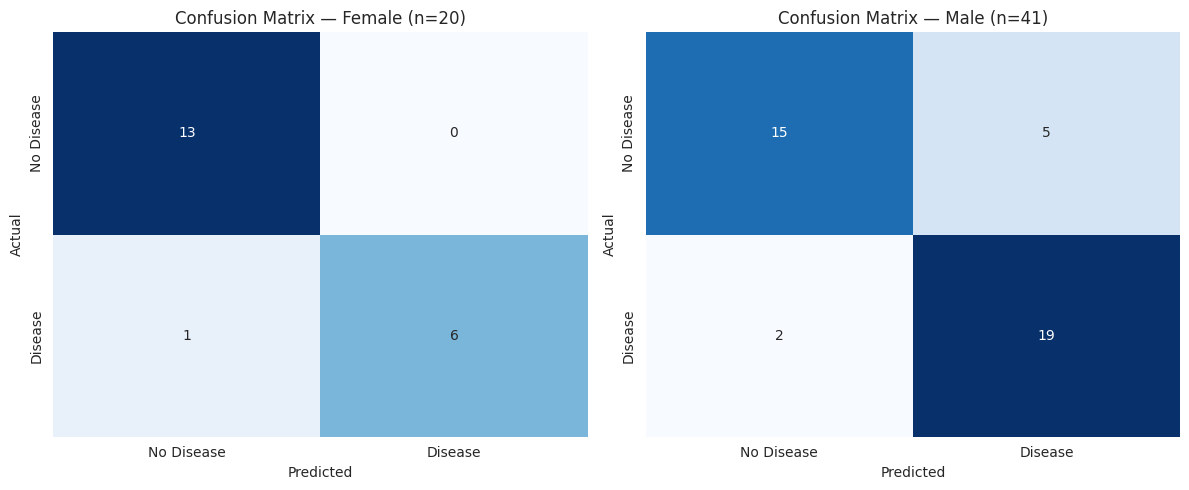

In [62]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, sex_val, label in zip(axes, [0, 1], ['Female', 'Male']):
    subset = analysis[analysis['sex'] == sex_val]
    if len(subset) == 0:
        continue

    cm = confusion_matrix(subset['actual'], subset['predicted'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix — {label} (n={len(subset)})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_by_sex.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 13: Exploratory Component — Principal Component Analysis

PCA is a dimensionality reduction technique that finds new axes (principal
components) capturing the greatest variance in the data. We run it as an
exploratory step to understand feature redundancy and to visualise the data.

We do NOT add PCA to the final model — the dataset has only 13 features, all
clinically interpretable. Reducing them would sacrifice interpretability for
little gain. But running PCA lets us verify that assumption and gives us a
useful figure for the report.

In [63]:
from sklearn.decomposition import PCA

# Preprocess the training set (using the same preprocessor)
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Fit PCA on all components
pca = PCA()
pca.fit(X_train_preprocessed)

# Variance explained
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"Total components: {len(explained_var)}")
print(f"\nVariance explained by first 5 components:")
for i in range(5):
    print(f"  PC{i+1}: {explained_var[i]:.4f}  "
          f"(cumulative: {cumulative_var[i]:.4f})")

# How many components for 95% variance?
n_components_95 = int(np.argmax(cumulative_var >= 0.95) + 1)
print(f"\nComponents needed for 95% variance: {n_components_95}")

Total components: 20

Variance explained by first 5 components:
  PC1: 0.2758  (cumulative: 0.2758)
  PC2: 0.1631  (cumulative: 0.4390)
  PC3: 0.1257  (cumulative: 0.5647)
  PC4: 0.1013  (cumulative: 0.6660)
  PC5: 0.0660  (cumulative: 0.7320)

Components needed for 95% variance: 13


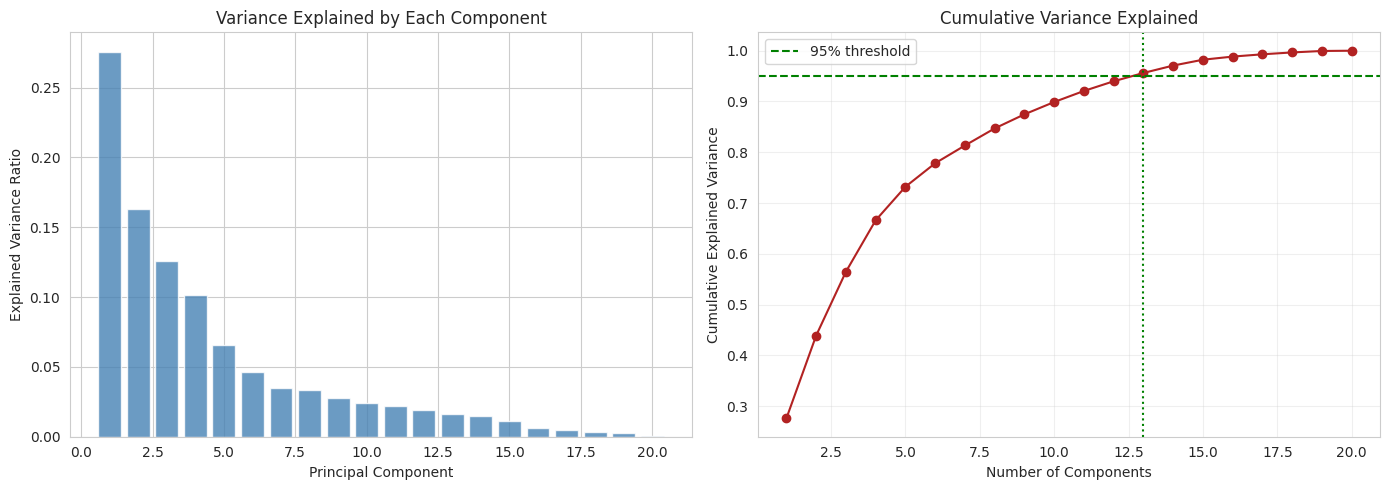

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot: variance per component
axes[0].bar(range(1, len(explained_var) + 1),
            explained_var, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Explained by Each Component')

# Cumulative plot
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var,
             marker='o', color='firebrick')
axes[1].axhline(y=0.95, color='green', linestyle='--',
                label='95% threshold')
axes[1].axvline(x=n_components_95, color='green', linestyle=':')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=100, bbox_inches='tight')
plt.show()

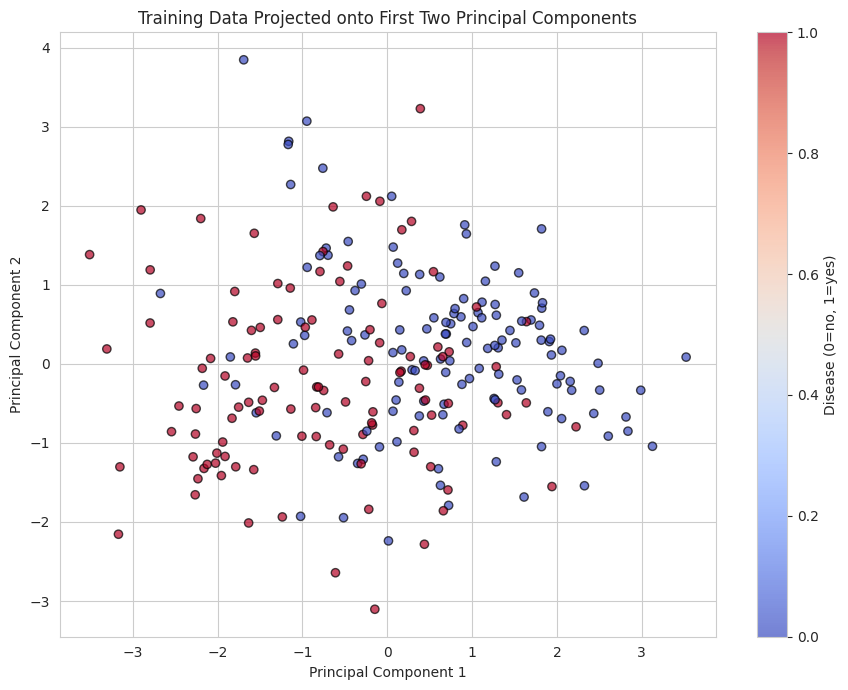

First two components explain 0.4390 of total variance.


In [65]:
# Reduce to 2 components for visualisation
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_preprocessed)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=y_train, cmap='coolwarm',
                      edgecolor='k', alpha=0.7)
plt.colorbar(scatter, label='Disease (0=no, 1=yes)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Training Data Projected onto First Two Principal Components')
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"First two components explain "
      f"{pca_2d.explained_variance_ratio_.sum():.4f} "
      f"of total variance.")

### Justification for not using PCA in the final model

PCA requires {n_components_95} components to retain 95% of the variance in
this dataset. Since the original feature set has only 13 interpretable features,
reducing to {n_components_95} components saves little and eliminates the ability
to explain the model's predictions in clinical terms (e.g., "chest pain type is
the top predictor"). For a medical decision-support tool where interpretability
matters, keeping the original features is the right trade-off.

PCA served its purpose here as an exploratory step: the variance plot shows how
much information each successive component captures, and the 2D projection
gives a visual sense of how separable the two classes are.